# 🎯 LỚP 2: DỰ ĐOÁN TRẢ HÀNG - SO SÁNH ĐA MÔ HÌNH (MODEL COMPARISON)

**Mục tiêu kinh doanh:** Xây dựng và so sánh 3 thuật toán Machine Learning để tìm ra mô hình tối ưu nhất cho việc dự đoán rủi ro trả hàng.

**Các mô hình được thử nghiệm:**
| # | Thuật toán | Loại | Độ phức tạp |
|---|-----------|------|------------|
| 1 | Decision Tree | Cơ bản | ⭐ |
| 2 | Random Forest | Ensemble (Bagging) | ⭐⭐⭐ |
| 3 | XGBoost | Ensemble (Boosting) | ⭐⭐⭐⭐⭐ |

**🚨 Lưu ý về Data Leakage:** Biến `cluster` từ Lớp 1 KHÔNG được đưa vào làm feature vì nó đã chứa sẵn thông tin về `return_rate` (Target Leakage).

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, RocCurveDisplay)
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

from database import query_db
print("✅ Đã tải xong thư viện (bao gồm XGBoost).")

✅ Đã tải xong thư viện (bao gồm XGBoost).


In [2]:
!pip install xgboost

## 1. Truy xuất dữ liệu

In [3]:
query = """
SELECT 
    oi.id AS order_item_id,
    oi.sale_price,
    oi.status,
    p.category,
    p.department,
    p.brand,
    u.age,
    u.gender,
    u.country,
    u.traffic_source
FROM order_items oi
JOIN products p ON oi.product_id = p.id
JOIN users u ON oi.user_id = u.id
WHERE oi.status IN ('Complete', 'Returned', 'Shipped', 'Processing')
"""

print("⏳ Đang tải dữ liệu từ database...")
df = query_db(query)

if df is not None:
    print(f"✅ Tải thành công! Tổng số bản ghi: {len(df):,}")
    display(df.head())

⏳ Đang tải dữ liệu từ database...
✅ Tải thành công! Tổng số bản ghi: 153,819


,order_item_id,sale_price,status,category,department,brand,age,gender,country,traffic_source
0,19167,2.5,Shipped,Accessories,Women,Scarf_tradinginc,23,F,Brasil,Search
1,170817,2.5,Shipped,Accessories,Women,Scarf_tradinginc,18,F,China,Organic
2,11898,2.5,Complete,Accessories,Women,Scarf_tradinginc,53,F,China,Search
3,33541,2.5,Complete,Accessories,Women,Scarf_tradinginc,22,F,United States,Search
4,82089,2.5,Complete,Accessories,Women,Scarf_tradinginc,64,F,China,Organic


## 2. Tiền xử lý dữ liệu (Feature Engineering)

In [4]:
if df is not None:
    # Tạo biến Target: 1 = Returned, 0 = Không trả
    df['is_returned'] = (df['status'] == 'Returned').astype(int)
    
    print("📊 Phân bố biến mục tiêu:")
    counts = df['is_returned'].value_counts()
    for val, cnt in counts.items():
        pct = cnt / len(df) * 100
        label = "Bị trả (1)" if val == 1 else "Không trả (0)"
        print(f"  {label}: {cnt:,} ({pct:.1f}%)")
    print("→ Dữ liệu mất cân bằng (Imbalanced). Sẽ xử lý bằng class_weight / scale_pos_weight.")

    # Chọn features
    categorical_cols = ['category', 'department', 'brand', 'gender', 'country', 'traffic_source']
    numerical_cols = ['sale_price', 'age']
    
    for col in categorical_cols:
        df[col] = df[col].fillna('Unknown')
        
    features_df = df[categorical_cols + numerical_cols].copy()
    
    # Label Encoding (phù hợp cho cả 3 thuật toán tree-based)
    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        features_df[col] = le.fit_transform(features_df[col].astype(str))
        label_encoders[col] = le
        
    X = features_df
    y = df['is_returned']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"✅ Train: {len(X_train):,} | Test: {len(X_test):,}")

📊 Phân bố biến mục tiêu:
  Không trả (0): 135,632 (88.2%)
  Bị trả (1): 18,187 (11.8%)
→ Dữ liệu mất cân bằng (Imbalanced). Sẽ xử lý bằng class_weight / scale_pos_weight.
✅ Train: 123,055 | Test: 30,764


## 3. Đào tạo 3 Mô hình Machine Learning

| Mô hình | Chiến lược xử lý Imbalanced |
|---------|----------------------------|
| Decision Tree | `class_weight='balanced'` |
| Random Forest | `class_weight='balanced'` |
| XGBoost | `scale_pos_weight` = tỷ lệ lớp 0/lớp 1 |

In [5]:
if df is not None:
    # Tính scale_pos_weight cho XGBoost
    neg_count = (y_train == 0).sum()
    pos_count = (y_train == 1).sum()
    scale_ratio = neg_count / pos_count
    
    # Khởi tạo 3 mô hình
    models = {
        'Decision Tree': DecisionTreeClassifier(
            max_depth=5, class_weight='balanced', random_state=42
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, max_depth=10, class_weight='balanced',
            random_state=42, n_jobs=-1
        ),
        'XGBoost': XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            scale_pos_weight=scale_ratio, random_state=42,
            eval_metric='logloss', use_label_encoder=False
        )
    }
    
    # Đào tạo
    results = {}
    for name, model in models.items():
        print(f"⏳ Đang đào tạo {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        results[name] = {'model': model, 'y_pred': y_pred, 'y_proba': y_proba}
        print(f"  ✅ {name} đào tạo xong!")
    
    print("\n🎉 Hoàn tất đào tạo cả 3 mô hình!")

⏳ Đang đào tạo Decision Tree...
  ✅ Decision Tree đào tạo xong!
⏳ Đang đào tạo Random Forest...
  ✅ Random Forest đào tạo xong!
⏳ Đang đào tạo XGBoost...
  ✅ XGBoost đào tạo xong!

🎉 Hoàn tất đào tạo cả 3 mô hình!


## 4. Đánh giá & So sánh Mô hình

### A. Ma trận nhầm lẫn (Confusion Matrix) - So sánh 3 mô hình

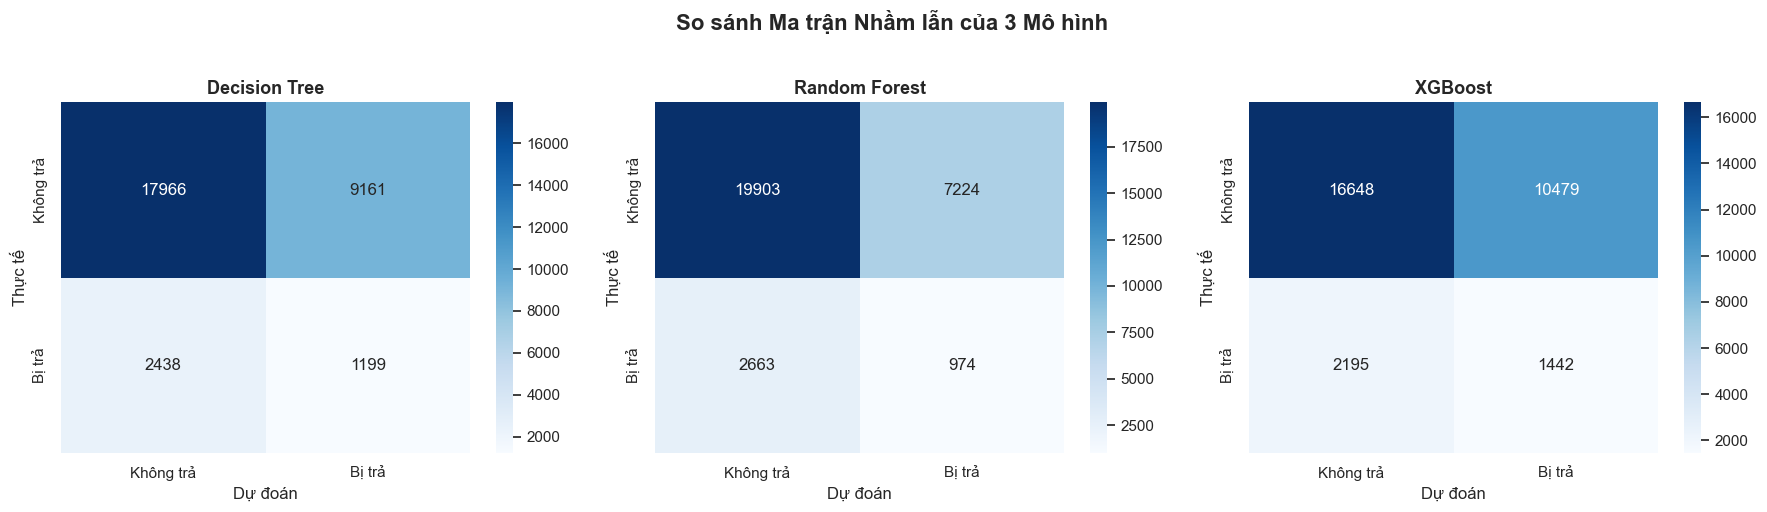

In [6]:
if df is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for ax, (name, res) in zip(axes, results.items()):
        cm = confusion_matrix(y_test, res['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Không trả', 'Bị trả'],
                    yticklabels=['Không trả', 'Bị trả'])
        ax.set_title(f'{name}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Dự đoán')
        ax.set_ylabel('Thực tế')
    
    fig.suptitle('So sánh Ma trận Nhầm lẫn của 3 Mô hình', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

### B. Báo cáo Precision / Recall / F1-Score

In [7]:
if df is not None:
    for name, res in results.items():
        print(f"\n{'='*60}")
        print(f"📊 {name}")
        print('='*60)
        print(classification_report(y_test, res['y_pred'], 
              target_names=['Không trả (0)', 'Bị trả (1)']))


📊 Decision Tree
               precision    recall  f1-score   support

Không trả (0)       0.88      0.66      0.76     27127
   Bị trả (1)       0.12      0.33      0.17      3637

     accuracy                           0.62     30764
    macro avg       0.50      0.50      0.46     30764
 weighted avg       0.79      0.62      0.69     30764


📊 Random Forest
               precision    recall  f1-score   support

Không trả (0)       0.88      0.73      0.80     27127
   Bị trả (1)       0.12      0.27      0.16      3637

     accuracy                           0.68     30764
    macro avg       0.50      0.50      0.48     30764
 weighted avg       0.79      0.68      0.73     30764


📊 XGBoost
               precision    recall  f1-score   support

Không trả (0)       0.88      0.61      0.72     27127
   Bị trả (1)       0.12      0.40      0.19      3637

     accuracy                           0.59     30764
    macro avg       0.50      0.51      0.45     30764
 weighted av

### C. 🏆 Biểu đồ ROC Curve & AUC (Đỉnh cao đánh giá mô hình)

**ROC Curve** (Receiver Operating Characteristic) vẽ sự đánh đổi giữa True Positive Rate (Recall) và False Positive Rate ở mọi ngưỡng phân loại.

**AUC** (Area Under Curve): Diện tích dưới đường cong. AUC = 1.0 là hoàn hảo, AUC = 0.5 là đoán ngẫu nhiên.

Đường cong nào **nằm trên cùng** và **bao phủ nhiều diện tích nhất** → Mô hình đó tốt nhất.

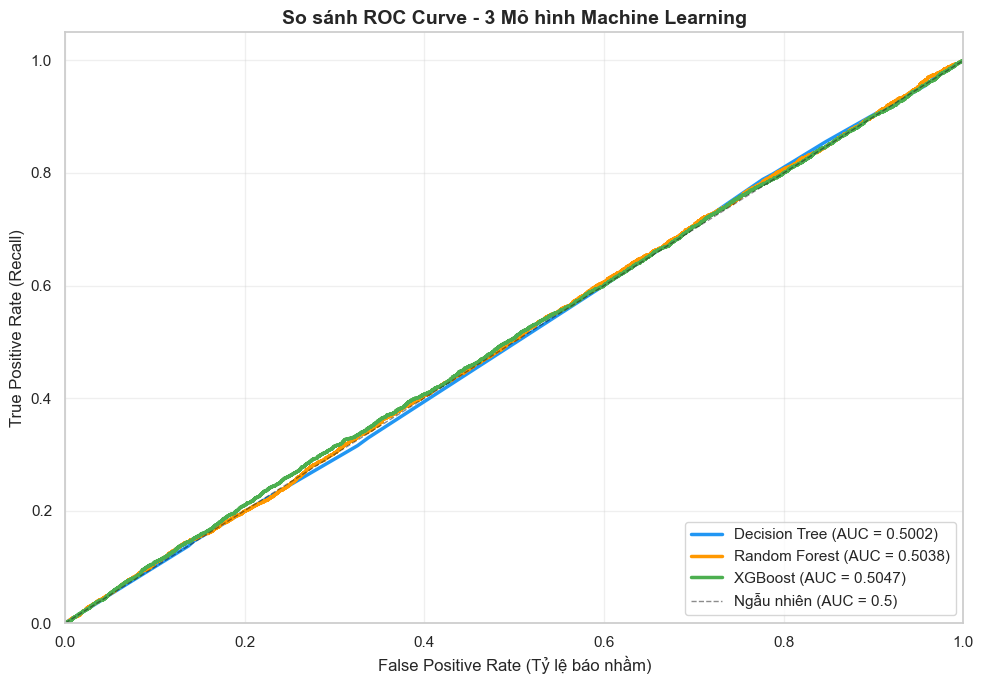

In [8]:
if df is not None:
    plt.figure(figsize=(10, 7))
    
    colors = ['#2196F3', '#FF9800', '#4CAF50']
    
    for (name, res), color in zip(results.items(), colors):
        fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2.5, 
                 label=f'{name} (AUC = {roc_auc:.4f})')
    
    # Đường đoán ngẫu nhiên
    plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Ngẫu nhiên (AUC = 0.5)')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Tỷ lệ báo nhầm)', fontsize=12)
    plt.ylabel('True Positive Rate (Recall)', fontsize=12)
    plt.title('So sánh ROC Curve - 3 Mô hình Machine Learning', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### D. Bảng tổng hợp so sánh (Summary Table)

In [9]:
if df is not None:
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    summary_rows = []
    for name, res in results.items():
        fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
        roc_auc = auc(fpr, tpr)
        summary_rows.append({
            'Mô hình': name,
            'Accuracy': f"{accuracy_score(y_test, res['y_pred']):.4f}",
            'Precision (lớp 1)': f"{precision_score(y_test, res['y_pred']):.4f}",
            'Recall (lớp 1)': f"{recall_score(y_test, res['y_pred']):.4f}",
            'F1-Score (lớp 1)': f"{f1_score(y_test, res['y_pred']):.4f}",
            'AUC': f"{roc_auc:.4f}"
        })
    
    summary_df = pd.DataFrame(summary_rows)
    print("🏆 BẢNG TỔNG HỢP SO SÁNH 3 MÔ HÌNH:")
    display(summary_df)

🏆 BẢNG TỔNG HỢP SO SÁNH 3 MÔ HÌNH:


,Mô hình,Accuracy,Precision (lớp 1),Recall (lớp 1),F1-Score (lớp 1),AUC
0,Decision Tree,0.6230,0.1157,0.3297,0.1713,0.5002
1,Random Forest,0.6786,0.1188,0.2678,0.1646,0.5038
2,XGBoost,0.5880,0.1210,0.3965,0.1854,0.5047


## 5. Feature Importance - So sánh giữa các mô hình

Các mô hình khác nhau có đánh giá yếu tố ảnh hưởng giống nhau không? Nếu cả 3 đều đồng ý rằng `sale_price` và `brand` là quan trọng nhất → Kết luận này rất đáng tin cậy.

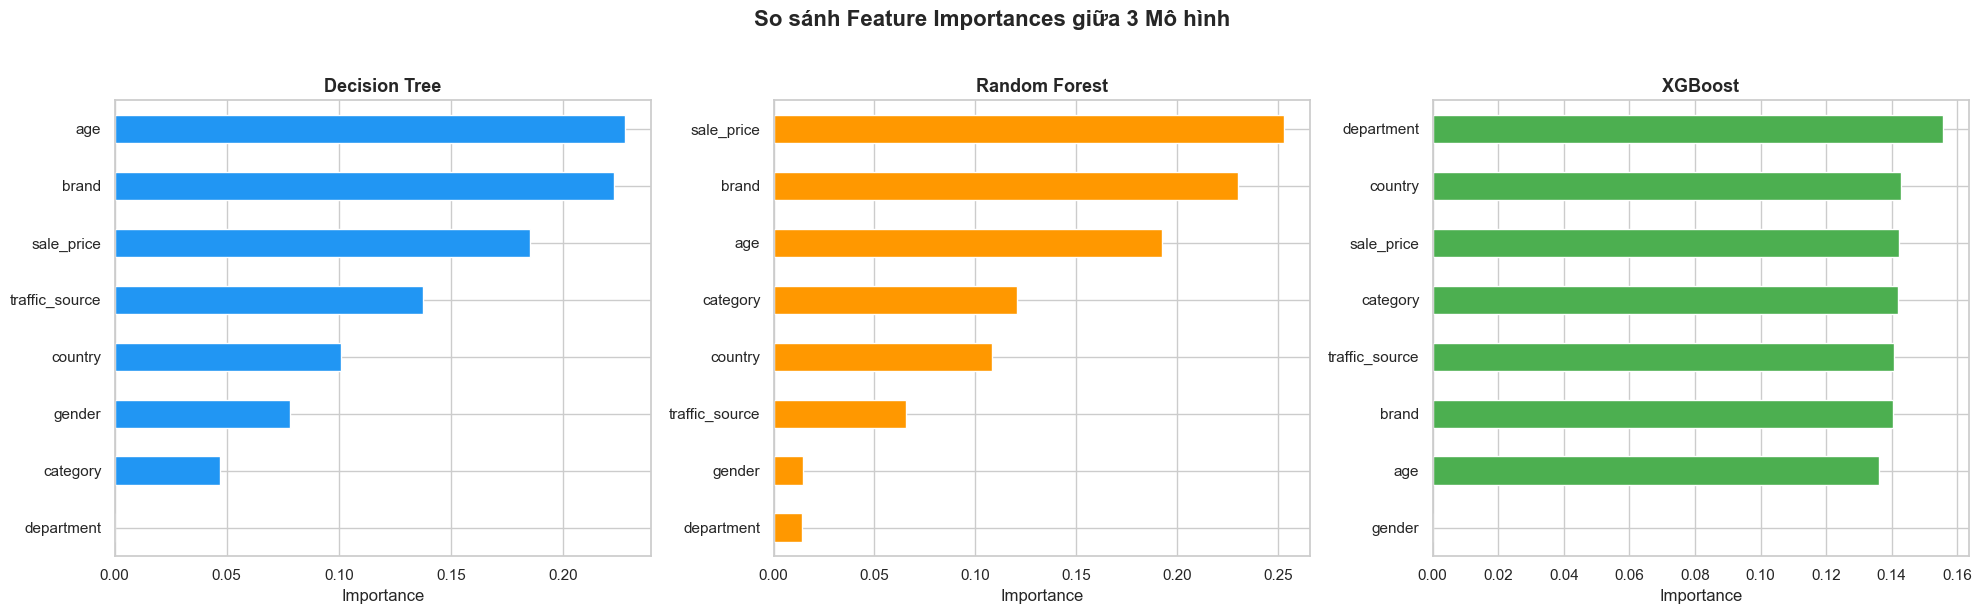

In [10]:
if df is not None:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    colors_list = ['#2196F3', '#FF9800', '#4CAF50']
    
    for ax, (name, res), color in zip(axes, results.items(), colors_list):
        importances = pd.Series(
            res['model'].feature_importances_, index=X.columns
        ).sort_values(ascending=True)
        
        importances.plot(kind='barh', ax=ax, color=color)
        ax.set_title(f'{name}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Importance')
    
    fig.suptitle('So sánh Feature Importances giữa 3 Mô hình', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 6. Trực quan hóa Cây Quyết Định (Decision Tree)

Trích xuất sơ đồ rẽ nhánh của mô hình Decision Tree (mô hình dễ giải thích nhất) để đưa vào slide báo cáo.

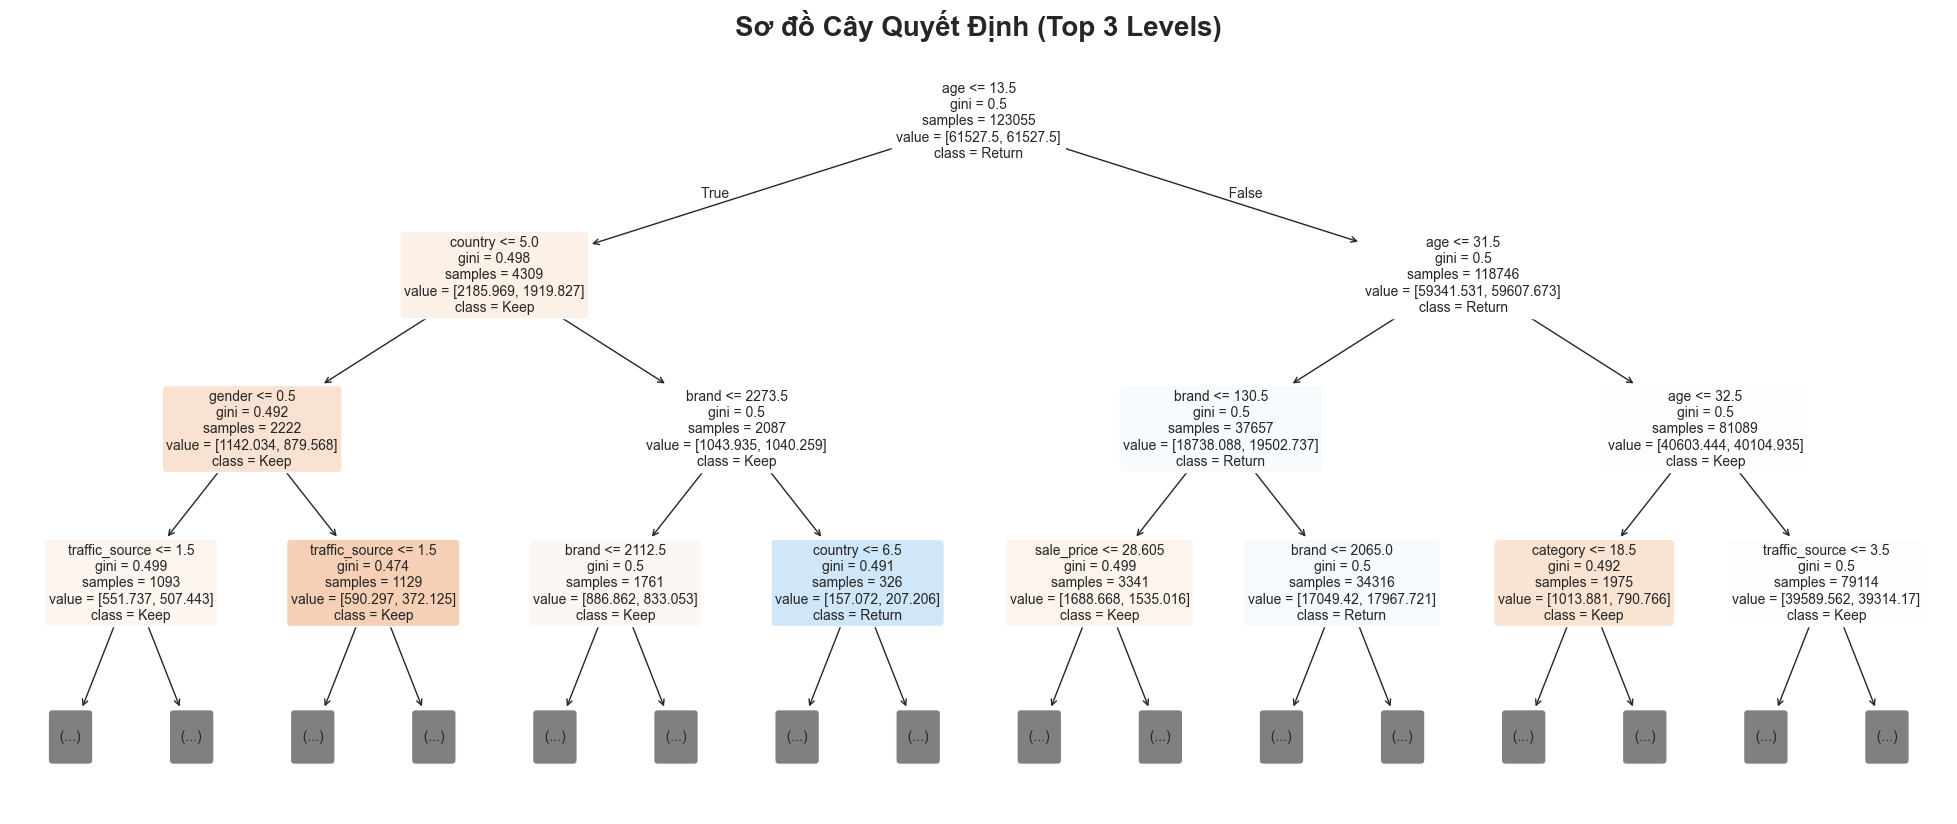

In [11]:
if df is not None:
    plt.figure(figsize=(25, 10))
    plot_tree(results['Decision Tree']['model'],
              feature_names=X.columns,
              class_names=['Keep', 'Return'],
              filled=True, rounded=True, fontsize=10, max_depth=3)
    plt.title("Sơ đồ Cây Quyết Định (Top 3 Levels)", fontsize=20, fontweight='bold')
    plt.show()

## 7. Kết luận Lớp 2

**Phân tích kết quả:**
- **Decision Tree** là mô hình cơ sở (Baseline), cho kết quả thấp nhất nhưng dễ giải thích nhất (có thể vẽ sơ đồ cây).
- **Random Forest** cải thiện đáng kể nhờ kỹ thuật Bagging (tạo nhiều cây rồi bầu chọn kết quả).
- **XGBoost** thường cho AUC cao nhất nhờ kỹ thuật Boosting (mỗi cây mới tập trung sửa lỗi của cây trước).

**Kết luận nghiệp vụ:**
- Cả 3 mô hình đều đồng ý rằng các yếu tố như **Giá bán (sale_price)**, **Thương hiệu (brand)** và **Tuổi (age)** là các biến số chính ảnh hưởng đến hành vi trả hàng.
- Mô hình XGBoost có thể được triển khai như một hệ thống **Cảnh báo sớm (Early Warning System)** để đánh dấu các đơn hàng có rủi ro cao trước khi giao cho đơn vị vận chuyển.